In [413]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [414]:
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [415]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 200
Columns: 5


In [416]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [417]:
df.duplicated().sum()

np.int64(0)

In [418]:
X=df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


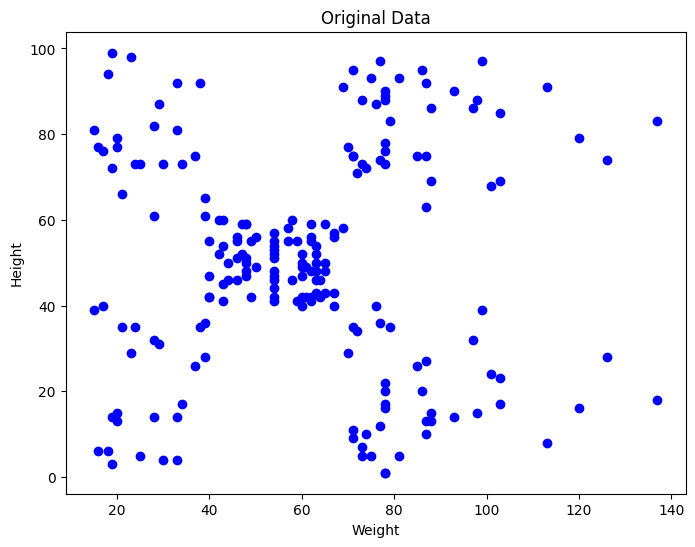

In [419]:
plt.figure(figsize=(8,6))
plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    color='blue'
)

plt.title("Original Data")
plt.xlabel("Weight")
plt.ylabel("Height")

plt.show()

In [420]:
scalar=StandardScaler()
X_scaled=scalar.fit_transform(X)

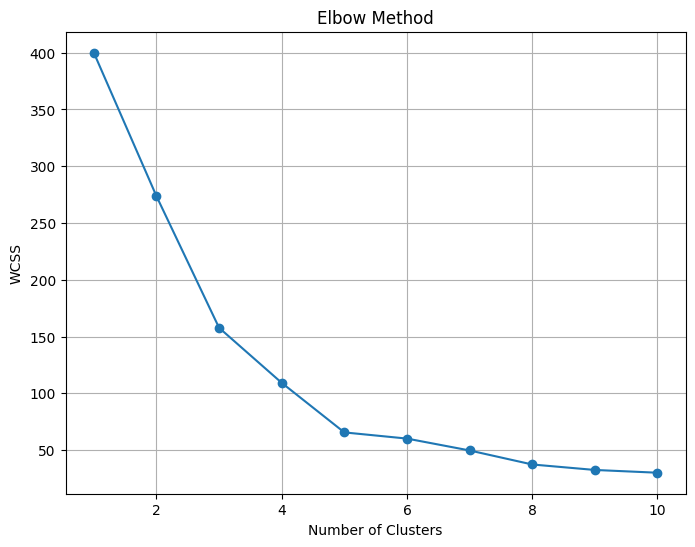

In [421]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [422]:
kmeans=KMeans(
    n_clusters=5,
    random_state=42
)
clusters = kmeans.fit_predict(X_scaled)

In [423]:
df["Cluster"] = clusters

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


In [424]:
centers = scalar.inverse_transform(kmeans.cluster_centers_)

print(centers)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


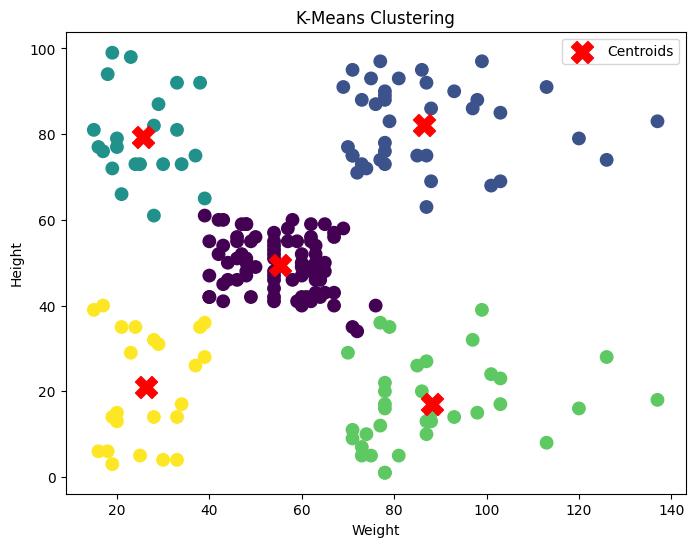

In [425]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=80
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    color="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("K-Means Clustering")

plt.xlabel("Weight")

plt.ylabel("Height")

plt.legend()

plt.show()

In [426]:
print(df["Cluster"].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [427]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


In [428]:
from sklearn.metrics import silhouette_score

In [429]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score :", round(score, 3))

Silhouette Score : 0.555


In [430]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

    print(f"K = {k}  --->  Silhouette Score = {score:.3f}")

K = 2  --->  Silhouette Score = 0.397
K = 3  --->  Silhouette Score = 0.467
K = 4  --->  Silhouette Score = 0.494
K = 5  --->  Silhouette Score = 0.555
K = 6  --->  Silhouette Score = 0.514
K = 7  --->  Silhouette Score = 0.502
K = 8  --->  Silhouette Score = 0.455
K = 9  --->  Silhouette Score = 0.457
K = 10  --->  Silhouette Score = 0.445


In [431]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

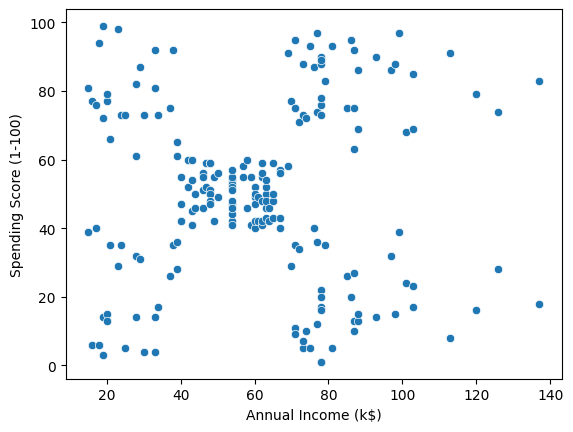

In [432]:
sns.scatterplot(data=df,x='Annual Income (k$)',y="Spending Score (1-100)")
plt.show()

In [433]:
print("\nMissing values:\n",df.isnull().sum())
df=df.dropna()


Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Cluster                   0
dtype: int64


In [434]:
X=df[['Annual Income (k$)','Spending Score (1-100)']]

In [435]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [436]:
min_samples=4

In [437]:
neighbors=NearestNeighbors(n_neighbors=min_samples)
neighbors_fit=neighbors.fit(X_scaled)
distances,indices=neighbors_fit.kneighbors(X_scaled)

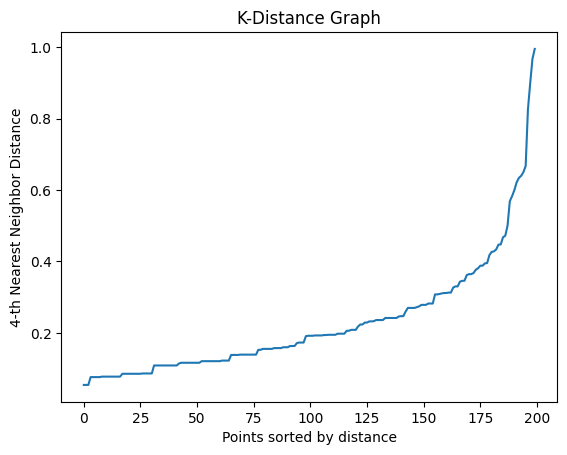

In [438]:
distances = np.sort(distances[:,min_samples-1])
plt.plot(distances)
plt.title("K-Distance Graph")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-th Nearest Neighbor Distance")
plt.show()

In [439]:
eps = 0.3
min_samples = 4
db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_scaled)

In [440]:
df['Cluster'] = labels
print("\nClustered data sample:\n", df.head())


Clustered data sample:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        2  
1        0  
2        1  
3        0  
4        2  


In [441]:
noise_points = sum(labels == -1)
print("\nNoise points:", noise_points)


Noise points: 23


In [442]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Number of clusters:", n_clusters)

Number of clusters: 8


In [443]:
if n_clusters > 1:
    sil_score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
    print("Silhouette Score:", sil_score)

Silhouette Score: 0.5197459953499523


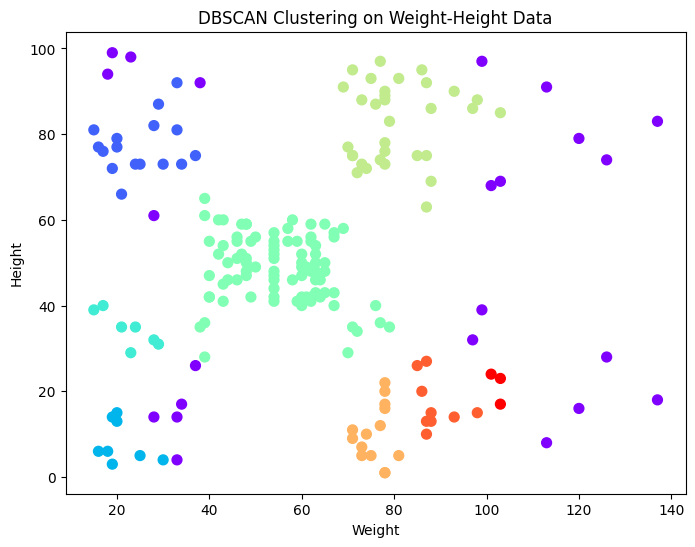

In [444]:
plt.figure(figsize=(8,6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'], cmap='rainbow', s=50)
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("DBSCAN Clustering on Weight-Height Data")
plt.show()

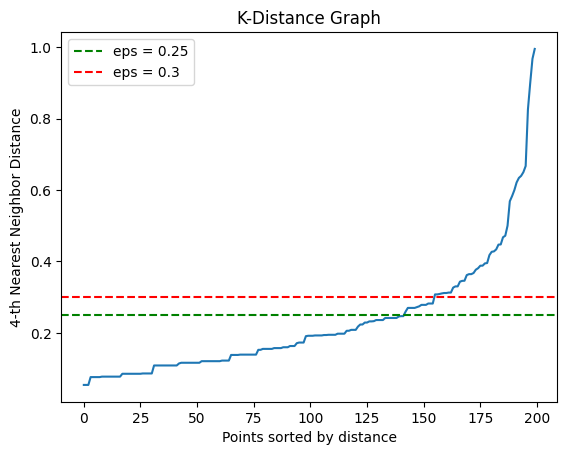

In [445]:

plt.plot(distances)
plt.title("K-Distance Graph")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-th Nearest Neighbor Distance")

plt.axhline(y=0.25, color='g', linestyle='--', label='eps = 0.25')
plt.axhline(y=0.3, color='r', linestyle='--', label='eps = 0.3')

plt.legend()
plt.show() 

In [446]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

In [447]:
X=df[['Annual Income (k$)','Spending Score (1-100)']]
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,0
4,5,Female,31,17,40,2


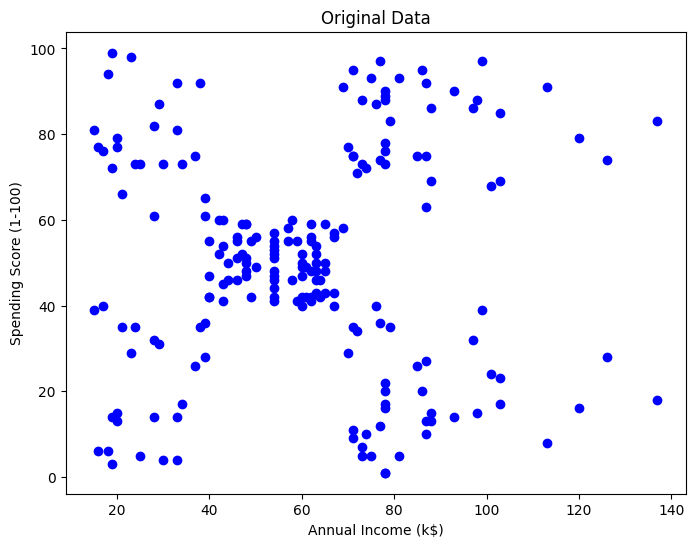

In [448]:
plt.figure(figsize=(8,6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    color='blue'
)

plt.title("Original Data")

plt.xlabel("Annual Income (k$)")

plt.ylabel("Spending Score (1-100)")

plt.show()

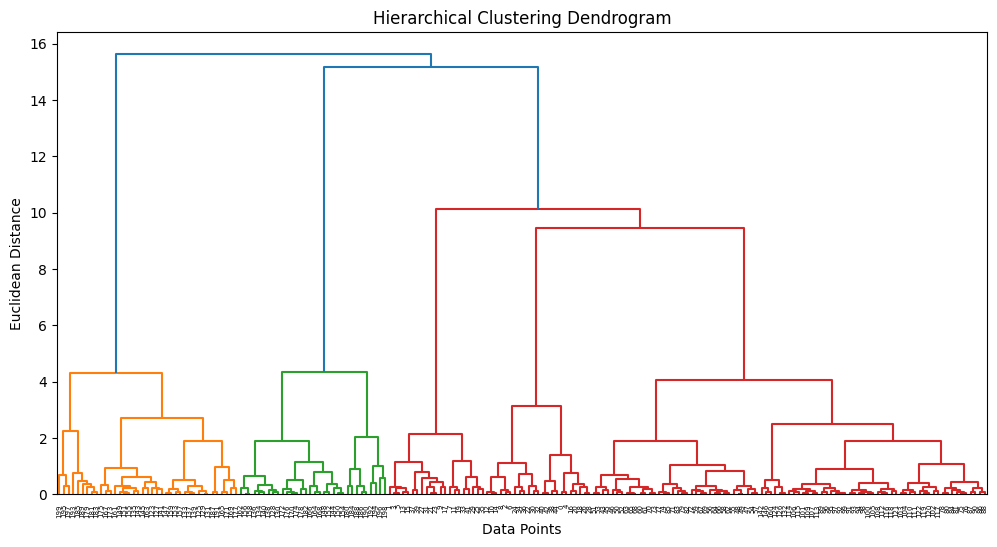

In [449]:

linked = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Data Points")

plt.ylabel("Euclidean Distance")

plt.show()

In [450]:
hc = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

clusters = hc.fit_predict(X_scaled)

In [451]:
df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


In [452]:
print(df["Cluster"].value_counts())

Cluster
0    129
1     39
2     32
Name: count, dtype: int64


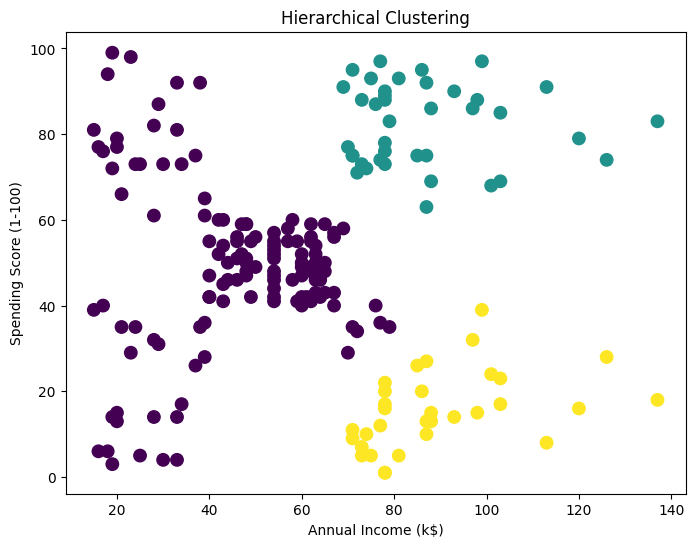

In [453]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=80
)

plt.title("Hierarchical Clustering")

plt.xlabel("Annual Income (k$)")

plt.ylabel("Spending Score (1-100)")

plt.show()

In [457]:
df.groupby("Cluster").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,65.596899,40.178295,45.550388,49.131783
1,162.000000,32.692308,86.538462,82.128205
2,166.250000,41.000000,89.406250,15.593750
